## Imports

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from collections import Counter
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import arch
from arch.univariate import ConstantMean, GARCH, Normal
import keras_tuner as kt
from imblearn.over_sampling import RandomOverSampler
import keras.backend as K
import os
import sys
sys.path.append('../Drafts')
from processing_module import round_hours

## Loading DOT Data

In [172]:
dot_prices  = pd.read_parquet('../Crypto_QTS_Data_Processed/dot_price_processed.parquet')
dot_staking = pd.read_parquet('../data/on_chain_data/processed/dot_staking_data.parquet')
dot_tech    = pd.read_parquet('../data/data_segmented_tech/dot_data.parquet')

dot_staking.index = pd.to_datetime(dot_staking.index)

dot_prices.index = pd.to_datetime(dot_prices.index)

dot_tech['time_close'] = pd.to_datetime(dot_tech['time_close'])
dot_tech['time_close'] = dot_tech['time_close'].dt.round('min')
dot_tech.set_index('time_close', inplace=True)

dot_features = dot_staking.copy()

global_start = max(dot_features.index.min(), dot_prices.index.min(), dot_tech.index.min())
global_end   = min(dot_features.index.max(), dot_prices.index.max(), dot_tech.index.max())

dot_features_aligned = dot_features.loc[global_start:global_end]
dot_prices_aligned   = dot_prices.loc[global_start:global_end]

dot_tech_aligned = dot_tech.loc[global_start:global_end].copy()

dot_prices_aligned = dot_prices_aligned[~dot_prices_aligned.index.duplicated(keep='first')]
dot_tech_aligned   = dot_tech_aligned[~dot_tech_aligned.index.duplicated(keep='first')]

dot_tech_aligned = dot_tech_aligned.reindex(dot_prices_aligned.index, method='nearest')

tech_cols = ['fib_23', 'fib_38', 'fib_50', 'fib_61', 'fib_78', 'bollinger', 'EMAcross', 'RSI']
dot_tech_selected = dot_tech_aligned[tech_cols].rename(columns=lambda x: "tech_" + x)

data = dot_features_aligned.join(
    dot_prices_aligned[['price_close']], 
    how='inner'
)

data = data.join(dot_tech_selected, how='left')

lag_cols = [ 
    'real_reward_rate',
    'staked_tokens', 'staking_ratio','active_validators'
]
tech_cols_renamed = ["tech_" + col for col in tech_cols]
all_lag_cols = lag_cols + tech_cols_renamed

data[all_lag_cols] = data[all_lag_cols].shift(1)

## Signal Loading

In [173]:
data['price_diff'] = data['price_close'].diff()

threshold_multiplier= 0.5
threshold = data['price_diff'].std() * threshold_multiplier

def get_signal(diff, threshold):
    if diff > threshold:
        return 'Buy'
    elif diff < -threshold:
        return 'Sell'
    else:
        return 'Hold'

data['Signal'] = data['price_diff'].apply(lambda x: get_signal(x, threshold))
data.dropna(inplace=True)

## Training

In [174]:
X = data[all_lag_cols].values
y = data['Signal'].values

label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(y)
y_cat = to_categorical(integer_encoded)

split_index = int(0.85 * len(X))

X_train = X[:split_index]
y_train = y_cat[:split_index]
X_test = X[split_index:]
y_test = y_cat[split_index:]

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

y_train_labels = label_encoder.inverse_transform(np.argmax(y_train, axis=1))

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64),
    LeakyReLU(negative_slope=0.1),
    Dense(32),
    LeakyReLU(negative_slope=0.1),
    Dense(y_cat.shape[1], activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    verbose=0
)

score_2 = model.evaluate(X_train, y_train, verbose=0)
scores = model.evaluate(X_test, y_test, verbose=0)
print(f"train accuracy: {score_2[1]*100:.2f}%")
print(f"Test accuracy: {scores[1]*100:.2f}%")
best_model = model

train accuracy: 72.69%
Test accuracy: 28.47%


## Confusion Matrix

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step


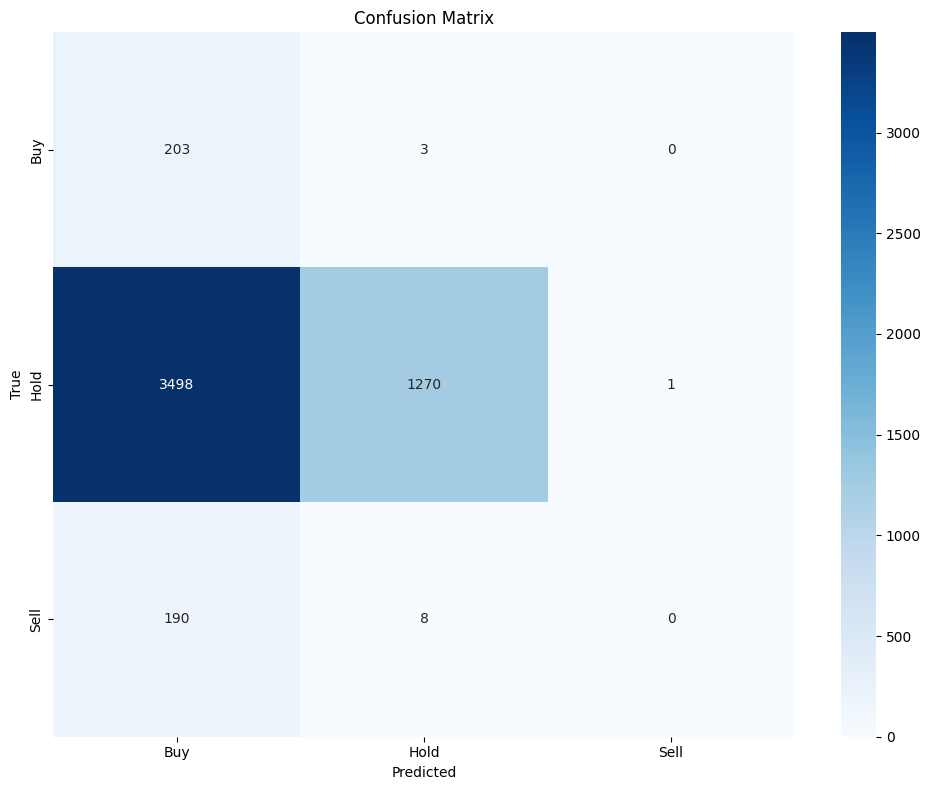


Classification Report:
              precision    recall  f1-score   support

         Buy       0.05      0.99      0.10       206
        Hold       0.99      0.27      0.42      4769
        Sell       0.00      0.00      0.00       198

    accuracy                           0.28      5173
   macro avg       0.35      0.42      0.17      5173
weighted avg       0.92      0.28      0.39      5173



In [175]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

class_names = label_encoder.classes_

cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(
    y_test_classes,
    y_pred_classes,
    target_names=class_names
))

## Testing Performance

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step

Trading Performance on Test Data:
Total PnL (percentage): 12.95%
Absolute PnL: $12,945.25
Annualized Sharpe Ratio: 0.1403


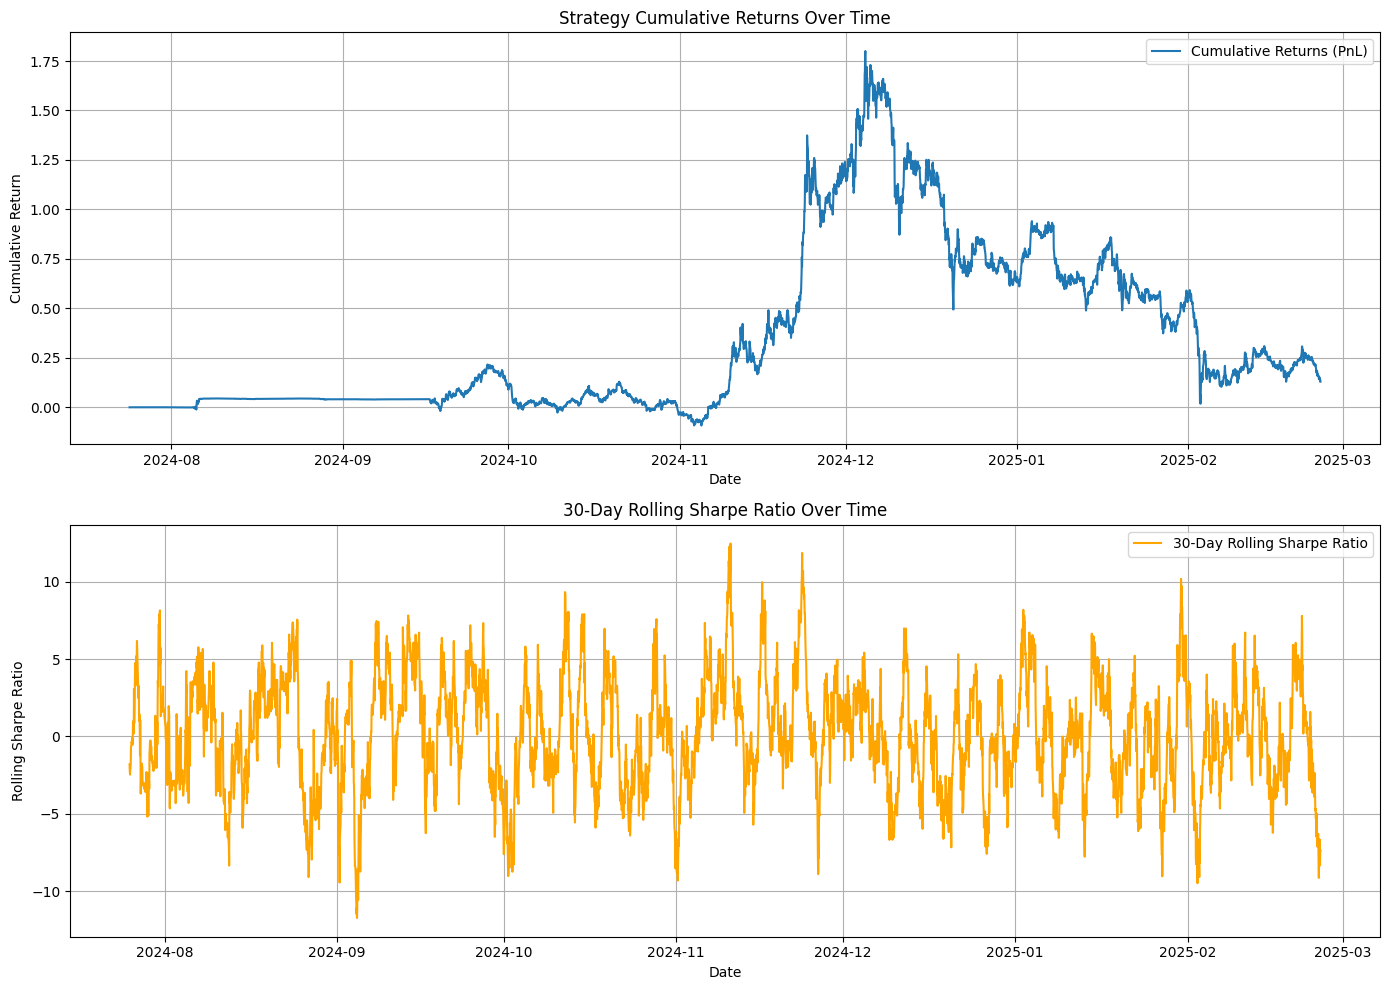

In [176]:
test_data = data.iloc[split_index:].copy()
test_data['asset_return'] = test_data['price_close'].pct_change()
test_data.dropna(inplace=True)

features_test_aligned = test_data[all_lag_cols].values
X_test_aligned = scaler.transform(features_test_aligned)

y_pred_test_aligned = best_model.predict(X_test_aligned)

positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]

asset_returns_test = test_data['asset_return'].values.astype(np.float32)
strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
strategy_returns_test[0] = 0

cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
total_pnl_percentage = cumulative_returns_test[-1]
sharpe_ratio_test = (np.mean(strategy_returns_test) / np.std(strategy_returns_test)) * np.sqrt(365)
initial_capital = 100000
absolute_pnl_test = total_pnl_percentage * initial_capital

print("\nTrading Performance on Test Data:")
print("Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
print("Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
print("Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))

dates = test_data.index
cumulative_returns_series = pd.Series(cumulative_returns_test, index=dates)
returns_series = pd.Series(strategy_returns_test, index=dates)

window = 30
rolling_sharpe = returns_series.rolling(window=window).apply(
    lambda r: (np.mean(r) / np.std(r) * np.sqrt(365)) if np.std(r) != 0 else 0,
    raw=True
)

plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(cumulative_returns_series.index, cumulative_returns_series, label='Cumulative Returns (PnL)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Strategy Cumulative Returns Over Time')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(rolling_sharpe.index, rolling_sharpe, label=f'{window}-Day Rolling Sharpe Ratio', color='orange')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe Ratio')
plt.title(f'{window}-Day Rolling Sharpe Ratio Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Performance Metrics

In [185]:
Btc_prices = pd.read_parquet('../Crypto_QTS_Data_Processed/btc_price_processed.parquet')

if not pd.api.types.is_datetime64_any_dtype(Btc_prices.index):
    Btc_prices.index = pd.to_datetime(Btc_prices.index)
Btc_prices.sort_index(inplace=True)

btc_returns = Btc_prices['price_close'].pct_change().dropna()

def compute_downside_beta(asset_returns, benchmark_returns, downside_threshold=0):

    if not isinstance(asset_returns, pd.Series):
        asset_returns = pd.Series(asset_returns)
    if not isinstance(benchmark_returns, pd.Series):
        benchmark_returns = pd.Series(benchmark_returns)
    
    common_idx = asset_returns.index.intersection(benchmark_returns.index)
    asset_downside = asset_returns.loc[common_idx]
    bench_downside = benchmark_returns.loc[common_idx]
    
    mask = bench_downside < downside_threshold
    if mask.sum() > 1 and np.var(bench_downside[mask]) != 0:
        downside_beta = np.cov(asset_downside[mask], bench_downside[mask])[0, 1] / np.var(bench_downside[mask])
    else:
        downside_beta = np.nan
    return downside_beta

def compute_performance_metrics(returns, freq_per_year=52, alpha=0.05, benchmark_returns=None, downside_threshold=0):
    
    if not isinstance(returns, pd.Series):
        returns = pd.Series(returns)
    
    mean_return_annual = returns.mean() * freq_per_year
    vol_annual = returns.std() * np.sqrt(freq_per_year)
    sharpe_ratio = mean_return_annual / vol_annual if vol_annual != 0 else np.nan
    
    cum_returns = (1 + returns).cumprod()
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max
    max_drawdown = drawdown.min()
    calmar_ratio = mean_return_annual / abs(max_drawdown) if max_drawdown != 0 else np.nan
    
    var_level = returns.quantile(alpha)
    var_95 = -var_level
    tail_losses = returns[returns <= var_level]
    cvar_95 = -tail_losses.mean() if len(tail_losses) > 0 else np.nan
    
    if benchmark_returns is not None:
        downside_beta = compute_downside_beta(returns, benchmark_returns, downside_threshold)
    else:
        downside_beta = np.nan
    
    metrics = {
        'mean_return_annual': mean_return_annual,
        'vol_annual': vol_annual,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'calmar_ratio': calmar_ratio,
        f'VaR_{int((1-alpha)*100)}': var_95,
        f'CVaR_{int((1-alpha)*100)}': cvar_95,
        'downside_beta (to BTC)': downside_beta,
    }
    
    return metrics

returns_series = pd.Series(strategy_returns_test, index=test_data.index)

freq_per_year = 365

performance_metrics = compute_performance_metrics(
    returns=returns_series,
    freq_per_year=freq_per_year,
    alpha=0.05,
    benchmark_returns=btc_returns,
    downside_threshold=0
)

print("Performance Metrics:")
for key, value in performance_metrics.items():
    print(f"{key}: {value}")


Performance Metrics:
mean_return_annual: 0.026675496250391006
vol_annual: 0.1901927150002941
sharpe_ratio: 0.14025508942521672
max_drawdown: -0.6364439725875854
calmar_ratio: 0.04191334545612335
VaR_95: 0.01457231747917831
CVaR_95: 0.024456728249788284
downside_beta (to BTC): 0.9627306747717281


## Fama-French Comparison

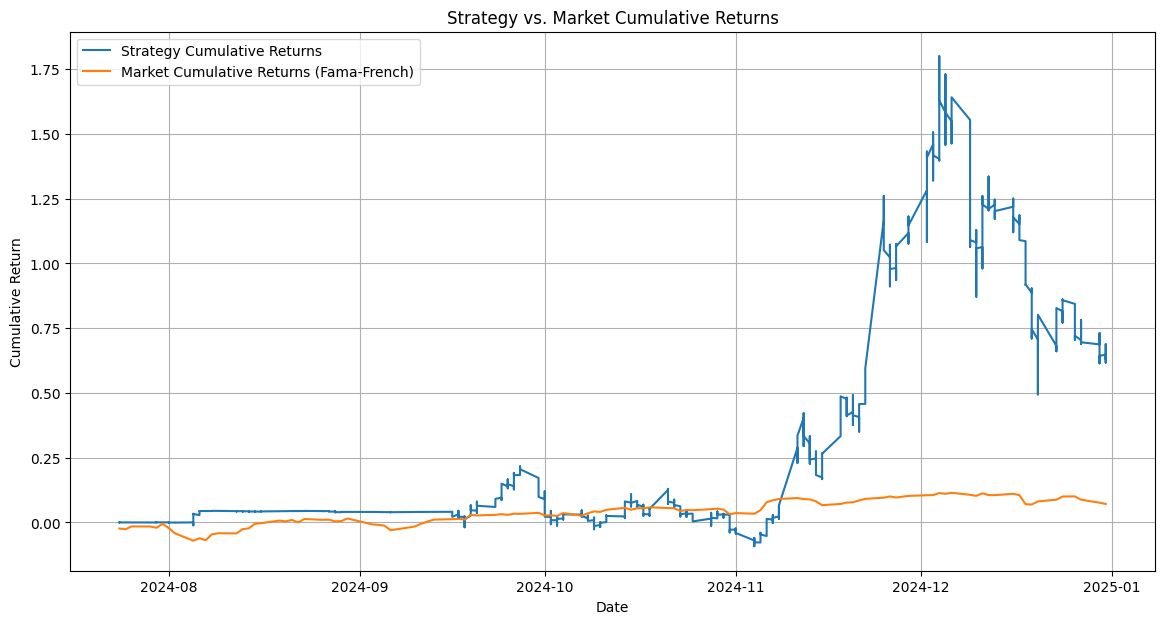

                            OLS Regression Results                            
Dep. Variable:        Strategy_Excess   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.722
Date:                Fri, 14 Mar 2025   Prob (F-statistic):             0.0429
Time:                        22:31:23   Log-Likelihood:                 8718.5
No. Observations:                2677   AIC:                        -1.743e+04
Df Residuals:                    2673   BIC:                        -1.741e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002      0.000     -1.036      0.3

In [178]:
header_row = None
with open('..\\data\\Fama_French_Data\\F-F_Research_Data_Factors_daily.csv', 'r') as f:
    for i, line in enumerate(f):
        if line.startswith(','):
            header_row = i
            break

if header_row is None:
    raise ValueError("Header row not found in the CSV file.")

ff_factors = pd.read_csv('..\\data\\Fama_French_Data\\F-F_Research_Data_Factors_daily.csv', 
                         skiprows=header_row, engine='python')

ff_factors.rename(columns={ff_factors.columns[0]: 'Date'}, inplace=True)
ff_factors.columns = ff_factors.columns.str.strip()

ff_factors = ff_factors[ff_factors['Date'].astype(str).str.match(r'^\d{8}$')]

ff_factors['Date'] = pd.to_datetime(ff_factors['Date'], format='%Y%m%d')
ff_factors.set_index('Date', inplace=True)
ff_factors = ff_factors.apply(pd.to_numeric)

ff_factors.index = pd.to_datetime(ff_factors.index)
ff_factors.sort_index(inplace=True)

ff_factors[['Mkt-RF', 'SMB', 'HML', 'RF']] /= 100.0

cumulative_returns_series.index = pd.to_datetime(cumulative_returns_series.index).tz_convert(None).normalize()
returns_series.index = pd.to_datetime(returns_series.index).tz_convert(None).normalize()

common_dates = cumulative_returns_series.index.intersection(ff_factors.index)
if common_dates.empty:
    raise ValueError("No overlapping dates found between strategy returns and ff_factors.")

strategy_cum_aligned = cumulative_returns_series.loc[common_dates]
strategy_returns_aligned = returns_series.loc[common_dates]
ff_aligned = ff_factors.loc[common_dates]

market_returns = ff_aligned['Mkt-RF'] + ff_aligned['RF']
cumulative_market_returns = np.cumprod(1 + market_returns) - 1

plt.figure(figsize=(14, 7))
plt.plot(strategy_cum_aligned.index, strategy_cum_aligned, label='Strategy Cumulative Returns')
plt.plot(ff_aligned.index, cumulative_market_returns, label='Market Cumulative Returns (Fama-French)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Strategy vs. Market Cumulative Returns')
plt.legend()
plt.grid(True)
plt.show()

strategy_excess = strategy_returns_aligned - ff_aligned['RF']

df_reg = pd.DataFrame({
    'Strategy_Excess': strategy_excess,
    'Mkt_RF': ff_aligned['Mkt-RF'],
    'SMB': ff_aligned['SMB'] if 'SMB' in ff_aligned.columns else 0,
    'HML': ff_aligned['HML'] if 'HML' in ff_aligned.columns else 0
}).dropna()

X = df_reg[['Mkt_RF', 'SMB', 'HML']]
X = sm.add_constant(X)
y = df_reg['Strategy_Excess']

model = sm.OLS(y, X).fit()
print(model.summary())


In [179]:
"""num_runs = 10
total_pnl_list = []
absolute_pnl_list = []
sharpe_ratio_list = []

model_list = []

for run in range(num_runs):
    print(f"\nTraining run {run+1}/{num_runs}")
    
    model_run = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64),
        LeakyReLU(negative_slope=0.1),
        Dense(32),
        LeakyReLU(negative_slope=0.1),
        Dense(y_cat.shape[1], activation='softmax')
    ])
    model_run.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    model_run.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )
    scores_1 = model_run.evaluate(X_test, y_test, verbose=0)
    scores_2 = model_run.evaluate(X_train, y_train, verbose=0)
    print(f"Train accuracy: {scores_2[1]*100:.2f}%")
    print(f"Test accuracy: {scores_1[1]*100:.2f}%")
    model_list.append(model_run)
    
    test_data_run = test_data.copy()
    test_data_run['asset_return'] = test_data_run['price_close'].pct_change()
    strategy_data = test_data_run.dropna().copy()
    
    features_test_aligned = strategy_data[all_lag_cols].values
    X_test_aligned = scaler.transform(features_test_aligned)
    
    y_pred_test_aligned = model_run.predict(X_test_aligned)
    
    positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]
    
    asset_returns_test = strategy_data['asset_return'].values.astype(np.float32)
    strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
    strategy_returns_test[0] = 0

    cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
    total_pnl_percentage = cumulative_returns_test[-1]
    
    std_returns = np.std(strategy_returns_test)
    if std_returns != 0:
        sharpe_ratio_test = (np.mean(strategy_returns_test) / std_returns) * np.sqrt(365)
    else:
        sharpe_ratio_test = 0
        
    initial_capital = 100000
    absolute_pnl_test = total_pnl_percentage * initial_capital
    
    print(f"Run {run+1} Trading Performance:")
    print("  Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
    print("  Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
    print("  Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))
    
    total_pnl_list.append(total_pnl_percentage)
    absolute_pnl_list.append(absolute_pnl_test)
    sharpe_ratio_list.append(sharpe_ratio_test)

avg_total_pnl = np.mean(total_pnl_list)
avg_absolute_pnl = np.mean(absolute_pnl_list)
avg_sharpe_ratio = np.mean(sharpe_ratio_list)

print("\nAverage Trading Performance over {} runs:".format(num_runs))
print("  Average Total PnL (percentage): {:.2%}".format(avg_total_pnl))
print("  Average Absolute PnL: ${:,.2f}".format(avg_absolute_pnl))
print("  Average Annualized Sharpe Ratio: {:.4f}".format(avg_sharpe_ratio))
"""

'num_runs = 10\ntotal_pnl_list = []\nabsolute_pnl_list = []\nsharpe_ratio_list = []\n\nmodel_list = []\n\nfor run in range(num_runs):\n    print(f"\nTraining run {run+1}/{num_runs}")\n\n    model_run = Sequential([\n        Input(shape=(X_train.shape[1],)),\n        Dense(64),\n        LeakyReLU(negative_slope=0.1),\n        Dense(32),\n        LeakyReLU(negative_slope=0.1),\n        Dense(y_cat.shape[1], activation=\'softmax\')\n    ])\n    model_run.compile(optimizer=\'adam\', loss=\'categorical_crossentropy\', metrics=[\'accuracy\'])\n\n    model_run.fit(\n        X_train, y_train,\n        epochs=50,\n        batch_size=32,\n        validation_split=0.2,\n        verbose=0\n    )\n    scores_1 = model_run.evaluate(X_test, y_test, verbose=0)\n    scores_2 = model_run.evaluate(X_train, y_train, verbose=0)\n    print(f"Train accuracy: {scores_2[1]*100:.2f}%")\n    print(f"Test accuracy: {scores_1[1]*100:.2f}%")\n    model_list.append(model_run)\n\n    test_data_run = test_data.copy()\